In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [4]:
weekly = pd.read_csv("workout_weekly_analysis.csv")

weekly.head()

,WEEK,MONTH,MUSCLE_GROUP,GYM_TYPE,PHASE,AVG_E1RM,AVG_RELATIVE_STRENGTH,TOTAL_VOLUME,E1RM_CHANGE,STRENGTH_TREND,REL_STRENGTH_CHANGE,RECOVERY_FLAG
0,1,Dec,Chest,Soro Gym,Bulk,41.925000,0.590077,2527.5,NaN,STABLE,NaN,RECOVERED
1,1,Dec,Triceps,Soro Gym,Bulk,44.958333,0.632770,2017.5,NaN,STABLE,0.042693,RECOVERED
2,1,Jan,Triceps,Soro Gym,Bulk,40.722222,0.560912,1630.0,-4.236111,DECREASING,-0.071858,RECOVERED
3,1,Dec,Back,Soro Gym,Bulk,52.814815,0.738153,3310.0,NaN,STABLE,0.177240,RECOVERED
4,1,Jan,Back,Soro Gym,Bulk,68.166667,0.938935,940.0,15.351852,INCREASING,0.200782,RECOVERED


Does training phase (Bulk vs Cut) significantly affect weekly strength adaptation?

In [6]:
weekly = weekly.sort_values(["MUSCLE_GROUP", "WEEK"])

weekly["NEXT_E1RM"] = (
    weekly.groupby("MUSCLE_GROUP")["AVG_E1RM"]
    .shift(-1)
)

weekly["STRENGTH_DELTA"] = weekly["NEXT_E1RM"] - weekly["AVG_E1RM"]

weekly = weekly.dropna(subset=["STRENGTH_DELTA"])

weekly.head()

,WEEK,MONTH,MUSCLE_GROUP,GYM_TYPE,PHASE,AVG_E1RM,AVG_RELATIVE_STRENGTH,TOTAL_VOLUME,E1RM_CHANGE,STRENGTH_TREND,REL_STRENGTH_CHANGE,RECOVERY_FLAG,NEXT_E1RM,STRENGTH_DELTA
3,1,Dec,Back,Soro Gym,Bulk,52.814815,0.738153,3310.0,NaN,STABLE,0.177240,RECOVERED,68.166667,15.351852
4,1,Jan,Back,Soro Gym,Bulk,68.166667,0.938935,940.0,15.351852,INCREASING,0.200782,RECOVERED,39.208333,-28.958333
19,2,Jan,Back,College Gym,Bulk,39.208333,0.551841,1732.5,NaN,STABLE,-0.045960,RECOVERED,40.750000,1.541667
25,3,Jan,Back,College Gym,Bulk,40.750000,0.566759,1935.0,1.541667,INCREASING,0.434709,RECOVERED,39.972222,-0.777778
28,4,Jan,Back,College Gym,Bulk,39.972222,0.556716,1720.0,-0.777778,DECREASING,0.166047,RECOVERED,41.416667,1.444444


In [7]:
weekly.groupby("PHASE")["STRENGTH_DELTA"].describe()

,count,mean,std,min,25%,50%,75%,max
PHASE,,,,,,,,
Bulk,153.0,0.649183,9.621453,-28.958333,-2.090278,0.550595,3.569444,65.055556
Cut,122.0,-0.734485,14.349705,-73.222222,-5.932986,0.830440,4.080729,37.907407


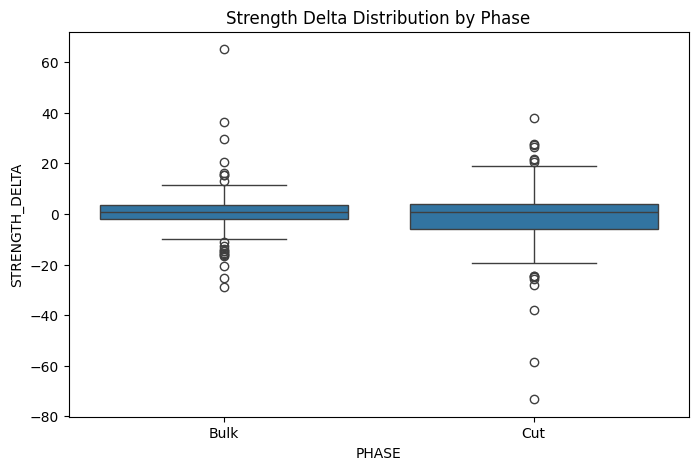

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=weekly, x="PHASE", y="STRENGTH_DELTA")
plt.title("Strength Delta Distribution by Phase")
plt.show()

In [11]:
bulk = weekly[weekly["PHASE"] == "Bulk"]["STRENGTH_DELTA"]
cut = weekly[weekly["PHASE"] == "Cut"]["STRENGTH_DELTA"]

t_stat, p_value = stats.ttest_ind(bulk, cut, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.9137815522159095
P-value: 0.3619179317256189


In [13]:
def cohens_d(x, y):
    pooled_std = np.sqrt(
        ((len(x) - 1)*np.var(x, ddof=1) + (len(y) - 1)*np.var(y, ddof=1))
        / (len(x) + len(y) - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std

effect_size = cohens_d(bulk, cut)

print("Cohen's d:", effect_size)

Cohen's d: 0.11578587438639916


Build Recovery Risk Model

In [15]:
weekly["DROP_FLAG"] = (weekly["STRENGTH_DELTA"] < 0).astype(int)

weekly["DROP_FLAG"].value_counts()

DROP_FLAG
0    161
1    114
Name: count, dtype: int64

In [17]:
weekly = weekly.sort_values(["MUSCLE_GROUP", "WEEK"])

# Create lag features
weekly["LAG1_E1RM"] = weekly.groupby("MUSCLE_GROUP")["AVG_E1RM"].shift(1)
weekly["LAG1_VOLUME"] = weekly.groupby("MUSCLE_GROUP")["TOTAL_VOLUME"].shift(1)
weekly["LAG1_STRENGTH_TREND"] = weekly.groupby("MUSCLE_GROUP")["STRENGTH_TREND"].shift(1)

# Drop missing from lag
weekly_model = weekly.dropna(subset=[
    "LAG1_E1RM",
    "LAG1_VOLUME",
    "LAG1_STRENGTH_TREND"
]).copy()

weekly_model.shape

(267, 18)

In [24]:
weekly_model = weekly_model.sort_values("WEEK")

split_week = int(weekly_model["WEEK"].max() * 0.8)

train = weekly_model[weekly_model["WEEK"] <= split_week]
test = weekly_model[weekly_model["WEEK"] > split_week]

print(train.shape, test.shape)

(208, 18) (59, 18)


In [25]:
features = [
    "LAG1_E1RM",
    "LAG1_VOLUME",
    "LAG1_STRENGTH_TREND",
    "PHASE",
    "MUSCLE_GROUP"
]

target = "DROP_FLAG"

X_train = train[features].copy()
X_test = test[features].copy()

y_train = train[target]
y_test = test[target]

categorical_cols = ["LAG1_STRENGTH_TREND", "PHASE", "MUSCLE_GROUP"]

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(X_train.shape)

(208, 11)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
log_probs = log_model.predict_proba(X_test)[:,1]

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [28]:
print("Logistic Regression")
print(classification_report(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))

print("\nRandom Forest")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

Logistic Regression
              precision    recall  f1-score   support

           0       0.58      0.91      0.71        32
           1       0.67      0.22      0.33        27

    accuracy                           0.59        59
   macro avg       0.62      0.56      0.52        59
weighted avg       0.62      0.59      0.54        59

ROC-AUC: 0.46874999999999994

Random Forest
              precision    recall  f1-score   support

           0       0.56      0.91      0.69        32
           1       0.57      0.15      0.24        27

    accuracy                           0.56        59
   macro avg       0.56      0.53      0.46        59
weighted avg       0.56      0.56      0.48        59

ROC-AUC: 0.583912037037037


In [31]:
importances = rf_model.feature_importances_

array([0.3730509 , 0.35190926, 0.03882206, 0.03975511, 0.04864389,
       0.02297569, 0.02737351, 0.02805694, 0.02487332, 0.02219062,
       0.02234871])